# ⚙️ UAV Battery Tool — Notebook 02: Equipment & Power Profile Builder

This notebook lets you:
- Browse the equipment database by category
- Inspect UAV configurations and compute per-phase power breakdowns
- Define custom flight parameters and auto-build a power profile
- Visualise the time-series power profile across all mission phases
- Export power profiles to CSV for use in simulation

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

from batteries.database import BatteryDatabase
from batteries.models   import (
    Equipment, UAVConfiguration, MissionPhase, MissionProfile
)

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 180)

DB_PATH = '../battery_db.xlsx'
db = BatteryDatabase(DB_PATH).load()
print(db.summary())

═══ Battery Database Summary ═══
  Chemistries       : 9
  Cells             : 11
  Battery packs     : 8
  Discharge points  : 132
  Equipment items   : 29
  UAV configurations: 3
  Mission profiles  : 3


---
## 1 · Equipment Database

In [2]:
eq_rows = []
for e in db.equipment.values():
    eq_rows.append({
        'ID': e.equip_id,
        'Category': e.category,
        'Make': e.manufacturer,
        'Model': e.model,
        'Idle (W)': e.idle_power_w,
        'Hover (W)': e.hover_power_w,
        'Climb (W)': e.climb_power_w,
        'Cruise (W)': e.cruise_power_w,
        'Max (W)': e.max_power_w,
        'Weight (g)': e.weight_g,
    })
df_eq = pd.DataFrame(eq_rows).set_index('ID')
df_eq

,Category,Make,Model,Idle (W),Hover (W),Climb (W),Cruise (W),Max (W),Weight (g)
ID,,,,,,,,,
MOT_T_MOTOR_MN4014,Propulsion,T-Motor,MN4014 KV330,2.0,55.00,85.00,45.00,110.0,135.0
MOT_T_MOTOR_MN701S,Propulsion,T-Motor,MN701S KV85,3.0,90.00,140.00,75.00,200.0,220.0
MOT_SUNNYSKY_X2216,Propulsion,SunnySky,X2216 KV800,1.0,35.00,55.00,28.00,75.0,73.0
MOT_HOBBYWING_X8,Propulsion,Hobbywing,X8 Power System,3.0,100.00,160.00,80.00,220.0,268.0
ESC_FLAME_60A,Propulsion,Hobbywing,Flame 60A,3.0,3.00,3.00,3.00,5.0,38.0
ESC_FLAME_80A,Propulsion,Hobbywing,Flame 80A,3.0,3.00,3.00,3.00,5.0,56.0
FC_PIXHAWK_6C,Avionics,Holybro,Pixhawk 6C,3.0,4.00,4.00,4.00,6.0,65.0
FC_CUBE_ORANGE,Avionics,CubePilot,Cube Orange+,4.0,5.00,5.00,5.00,7.0,68.0
GPS_HERE3,Avionics,CubePilot,Here 3+ GPS,0.5,0.50,0.50,0.50,1.0,48.0


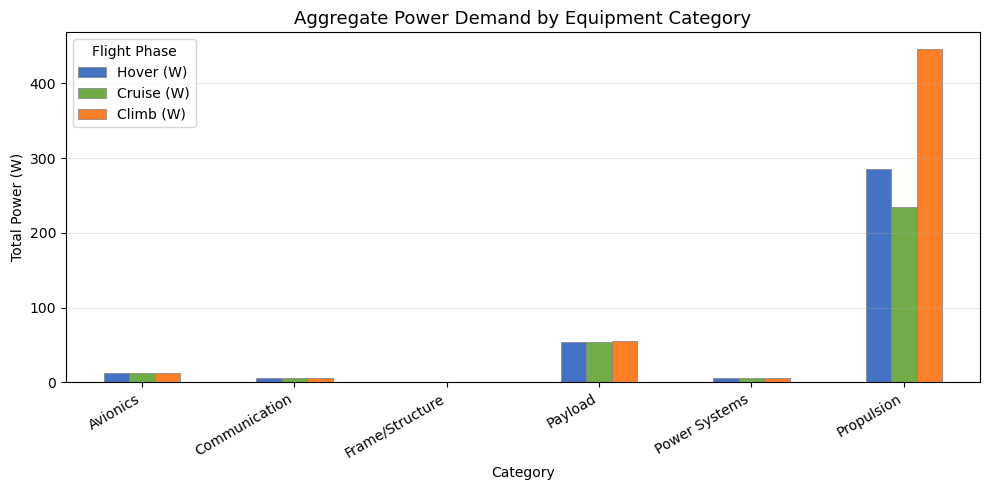

In [3]:
# Power draw by category (stacked bar)
cat_power = df_eq.groupby('Category')[['Hover (W)','Cruise (W)','Climb (W)']].sum()

fig, ax = plt.subplots(figsize=(10, 5))
cat_power.plot(kind='bar', ax=ax, color=['#4472C4','#70AD47','#FF7F27'], edgecolor='grey', linewidth=0.5)
ax.set_title('Aggregate Power Demand by Equipment Category', fontsize=13)
ax.set_ylabel('Total Power (W)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Flight Phase')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('equipment_power_by_category.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 2 · UAV Configurations

Inspect pre-configured UAVs from `UAV_Configurations` sheet.

In [4]:
for uid, cfg in db.uav_configs.items():
    print(f'\n{'─'*60}')
    print(f' {cfg.name}  [{uid}]')
    print(f'{'─'*60}')
    print(f'  Total weight  : {cfg.total_weight_g():.0f} g  ({cfg.total_weight_g()/1000:.2f} kg)')
    print(f'  Hover power   : {cfg.phase_power_w("HOVER"):.0f} W')
    print(f'  Cruise power  : {cfg.phase_power_w("CRUISE"):.0f} W')
    print(f'  Climb power   : {cfg.phase_power_w("CLIMB"):.0f} W')
    print(f'  Takeoff power : {cfg.phase_power_w("TAKEOFF"):.0f} W')
    print(f'  Idle power    : {cfg.phase_power_w("IDLE"):.0f} W')
    print(f'  Items         : {len(cfg.equipment_list)}')


────────────────────────────────────────────────────────────
 Survey Hex 900  [HEX_SURVEY_900]
────────────────────────────────────────────────────────────
  Total weight  : 3073 g  (3.07 kg)
  Hover power   : 368 W
  Cruise power  : 308 W
  Climb power   : 550 W
  Takeoff power : 721 W
  Idle power    : 42 W
  Items         : 11

────────────────────────────────────────────────────────────
 Ag Heavy Lift  [HEX_AG_1200]
────────────────────────────────────────────────────────────
  Total weight  : 4690 g  (4.69 kg)
  Hover power   : 636 W
  Cruise power  : 516 W
  Climb power   : 996 W
  Takeoff power : 1376 W
  Idle power    : 48 W
  Items         : 10

────────────────────────────────────────────────────────────
 Inspection Quad  [QUAD_INSPECT]
────────────────────────────────────────────────────────────
  Total weight  : 1492 g  (1.49 kg)
  Hover power   : 169 W
  Cruise power  : 141 W
  Climb power   : 251 W
  Takeoff power : 348 W
  Idle power    : 27 W
  Items         : 10


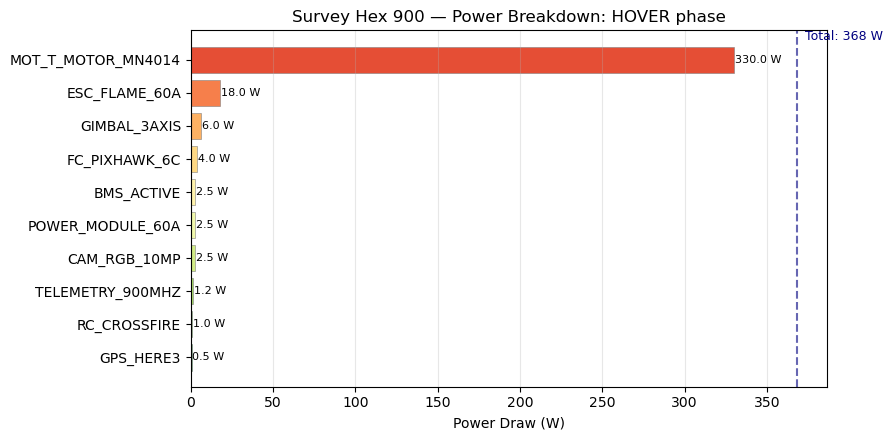

In [5]:
# Power breakdown waterfall for a specific UAV + phase
UAV_ID_PLOT = 'HEX_SURVEY_900'
PHASE_PLOT  = 'HOVER'

cfg_plot    = db.uav_configs[UAV_ID_PLOT]
breakdown   = cfg_plot.power_breakdown(PHASE_PLOT)

df_bkdn = (pd.Series(breakdown)
             .rename('Power (W)')
             .to_frame()
             .sort_values('Power (W)', ascending=True))
df_bkdn = df_bkdn[df_bkdn['Power (W)'] > 0]

fig, ax = plt.subplots(figsize=(9, max(4, len(df_bkdn) * 0.45)))
colors  = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(df_bkdn)))
bars = ax.barh(df_bkdn.index, df_bkdn['Power (W)'],
               color=colors, edgecolor='grey', linewidth=0.4)
for bar, val in zip(bars, df_bkdn['Power (W)']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} W', va='center', fontsize=8)

total_p = df_bkdn['Power (W)'].sum()
ax.axvline(total_p, linestyle='--', color='navy', alpha=0.6)
ax.text(total_p, len(df_bkdn) - 0.4, f'  Total: {total_p:.0f} W',
        color='navy', fontsize=9)
ax.set_xlabel('Power Draw (W)')
ax.set_title(f'{cfg_plot.name} — Power Breakdown: {PHASE_PLOT} phase', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'power_breakdown_{UAV_ID_PLOT}_{PHASE_PLOT}.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3 · Mission Profile Explorer

In [6]:
for mid, mission in db.missions.items():
    uav = db.uav_configs.get(mission.uav_config_id)
    total_e = mission.total_energy_wh(uav)
    print(f'\n{mission}')
    print(f'  UAV          : {mission.uav_config_id}')
    print(f'  Total energy : {total_e:.1f} Wh')

    phase_rows = []
    for ph in mission.phases:
        pw = ph.effective_power_w(uav)
        phase_rows.append({
            'Seq': ph.phase_seq,
            'Phase': ph.phase_name,
            'Type': ph.phase_type,
            'Duration (s)': ph.duration_s,
            'Power (W)': round(pw, 1),
            'Energy (Wh)': round(ph.energy_wh(uav), 2),
        })
    df_m = pd.DataFrame(phase_rows).set_index('Seq')
    display(df_m)


Mission 'Grid Survey 500m' (SURVEY_STD): 8 phases | 24.5 min | 6700m
  UAV          : HEX_SURVEY_900
  Total energy : 127.9 Wh


,Phase,Type,Duration (s),Power (W),Energy (Wh)
Seq,,,,,
1,Pre-arm checks,IDLE,60.0,42.5,0.71
2,Takeoff,TAKEOFF,30.0,721.0,6.01
3,Climb to alt,CLIMB,60.0,550.2,9.17
4,Survey grid,CRUISE,900.0,308.2,77.06
5,Hover waypoint,HOVER,30.0,368.2,3.07
6,Return home,CRUISE,300.0,308.2,25.69
7,Descend,DESCEND,60.0,215.8,3.60
8,Land,LAND,30.0,313.0,2.61



Mission 'Ag Spray 10ha' (AG_SPRAY): 9 phases | 18.5 min | 2640m
  UAV          : HEX_AG_1200
  Total energy : 152.8 Wh


,Phase,Type,Duration (s),Power (W),Energy (Wh)
Seq,,,,,
1,Pre-arm checks,IDLE,90.0,48.0,1.20
2,Takeoff,TAKEOFF,20.0,1375.5,7.64
3,Transit,CRUISE,120.0,515.9,17.20
4,Spray pass 1,CRUISE,240.0,515.9,34.39
5,Turn hover,HOVER,15.0,635.9,2.65
6,Spray pass 2,CRUISE,240.0,515.9,34.39
7,Spray pass 3,CRUISE,240.0,515.9,34.39
8,Return home,CRUISE,120.0,515.9,17.20
9,Land,LAND,25.0,540.5,3.75



Mission 'Tower Inspection' (INSPECT_STD): 8 phases | 14.2 min | 300m
  UAV          : QUAD_INSPECT
  Total energy : 37.5 Wh


,Phase,Type,Duration (s),Power (W),Energy (Wh)
Seq,,,,,
1,Pre-arm,IDLE,60.0,27.4,0.46
2,Takeoff,TAKEOFF,20.0,347.5,1.93
3,Climb,CLIMB,90.0,251.2,6.28
4,Orbit hover,HOVER,300.0,169.2,14.10
5,Slow orbit,CRUISE,240.0,141.2,9.42
6,Reposition,HOVER,60.0,169.2,2.82
7,Descend,DESCEND,60.0,98.9,1.65
8,Land,LAND,20.0,143.9,0.80


---
## 4 · Custom Mission Builder

Define a mission from scratch using flight parameters — the power profile is automatically computed from the UAV configuration.

In [7]:
# ── Load settings from 00_configurator.ipynb (analysis_config.json) ───────────
import json as _json, os as _os
_CFG_PATH = _os.path.join(_os.path.dirname(_os.path.abspath('.')), 'analysis_config.json')
if not _os.path.exists(_CFG_PATH):
    _CFG_PATH = 'analysis_config.json'
_cfg = {}
if _os.path.exists(_CFG_PATH):
    with open(_CFG_PATH) as _f:
        _cfg = _json.load(_f)
    print(f'Loaded config from {_CFG_PATH}')
else:
    print('No analysis_config.json found — using defaults below (run 00_configurator first)')

# ── Values from configurator (overridden by manual entries below if desired) ───
UAV_ID = _cfg.get('uav_id', 'HEX_SURVEY_900')
# ═══════════════════════════════════════════════════════════════
# MISSION DEFINITION — edit this section
# ═══════════════════════════════════════════════════════════════
# MISSION_ID   = 'MY_MISSION_01'
# MISSION_NAME = 'Custom Grid Survey'
# UAV_ID       = 'HEX_SURVEY_900'   # Must exist in UAV_Configurations

# Phase definitions:
# (phase_name, phase_type, duration_s, distance_m, altitude_m, airspeed_ms, power_override_W)
# Set power_override_W = None to use automatic calculation from UAV config
PHASES = [
    ('Pre-arm',          'IDLE',        90,    0,    0,   0,   None),
    ('Takeoff',          'TAKEOFF',     25,    0,    20,  3,   None),
    ('Climb to 80m',     'CLIMB',       55,    150,  80,  4,   None),
    ('Transit to AOI',   'CRUISE',      120,   800,  80,  8,   None),
    ('Grid survey row1', 'CRUISE',      375,  3000,  80,  8,   None),
    ('Turn hover',       'HOVER',       15,    0,    80,  0,   None),
    ('Grid survey row2', 'CRUISE',      375,  3000,  80,  8,   None),
    ('Turn hover',       'HOVER',       15,    0,    80,  0,   None),
    ('Grid survey row3', 'CRUISE',      375,  3000,  80,  8,   None),
    ('RTH cruise',       'CRUISE',      160,   800,  80,  8,   None),
    ('Descend',          'DESCEND',     55,    0,    10,  3,   None),
    ('Land',             'LAND',        20,    0,    0,   1,   None),
]
# ═══════════════════════════════════════════════════════════════

uav = db.uav_configs[UAV_ID]

mission_phases = [
    MissionPhase(
        mission_id=MISSION_ID,
        mission_name=MISSION_NAME,
        uav_config_id=UAV_ID,
        phase_seq=i + 1,
        phase_name=name,
        phase_type=ptype,
        duration_s=dur,
        distance_m=dist,
        altitude_m=alt,
        airspeed_ms=spd,
        power_override_w=pov,
    )
    for i, (name, ptype, dur, dist, alt, spd, pov) in enumerate(PHASES)
]

my_mission = MissionProfile(
    mission_id=MISSION_ID,
    mission_name=MISSION_NAME,
    uav_config_id=UAV_ID,
    phases=mission_phases,
)

# Summary
print(f'Mission: {my_mission.mission_name}')
print(f'  UAV             : {uav.name}')
print(f'  UAV weight      : {uav.total_weight_g():.0f} g')
print(f'  Total duration  : {my_mission.total_duration_s:.0f} s  '
      f'({my_mission.total_duration_s/60:.1f} min)')
print(f'  Total distance  : {my_mission.total_distance_m:.0f} m')
print(f'  Total energy    : {my_mission.total_energy_wh(uav):.1f} Wh')
print()

# Phase table
rows = []
t_acc = 0
for ph in my_mission.phases:
    pw = ph.effective_power_w(uav)
    rows.append({
        '#': ph.phase_seq,
        'Phase': ph.phase_name,
        'Type': ph.phase_type,
        'Duration (s)': ph.duration_s,
        'Distance (m)': ph.distance_m,
        'Altitude (m)': ph.altitude_m,
        'Speed (m/s)': ph.airspeed_ms,
        'Power (W)': round(pw, 1),
        'Energy (Wh)': round(ph.energy_wh(uav), 2),
        'Start T (s)': t_acc,
    })
    t_acc += ph.duration_s

df_my = pd.DataFrame(rows).set_index('#')
df_my

Mission: Custom Grid Survey
  UAV             : Survey Hex 900
  UAV weight      : 3073 g
  Total duration  : 1680 s  (28.0 min)
  Total distance  : 10750 m
  Total energy    : 142.9 Wh



,Phase,Type,Duration (s),Distance (m),Altitude (m),Speed (m/s),Power (W),Energy (Wh),Start T (s)
#,,,,,,,,,
1,Pre-arm,IDLE,90,0,0,0,42.5,1.06,0
2,Takeoff,TAKEOFF,25,0,20,3,721.0,5.01,90
3,Climb to 80m,CLIMB,55,150,80,4,550.2,8.41,115
4,Transit to AOI,CRUISE,120,800,80,8,308.2,10.28,170
5,Grid survey row1,CRUISE,375,3000,80,8,308.2,32.11,290
6,Turn hover,HOVER,15,0,80,0,368.2,1.53,665
7,Grid survey row2,CRUISE,375,3000,80,8,308.2,32.11,680
8,Turn hover,HOVER,15,0,80,0,368.2,1.53,1055
9,Grid survey row3,CRUISE,375,3000,80,8,308.2,32.11,1070


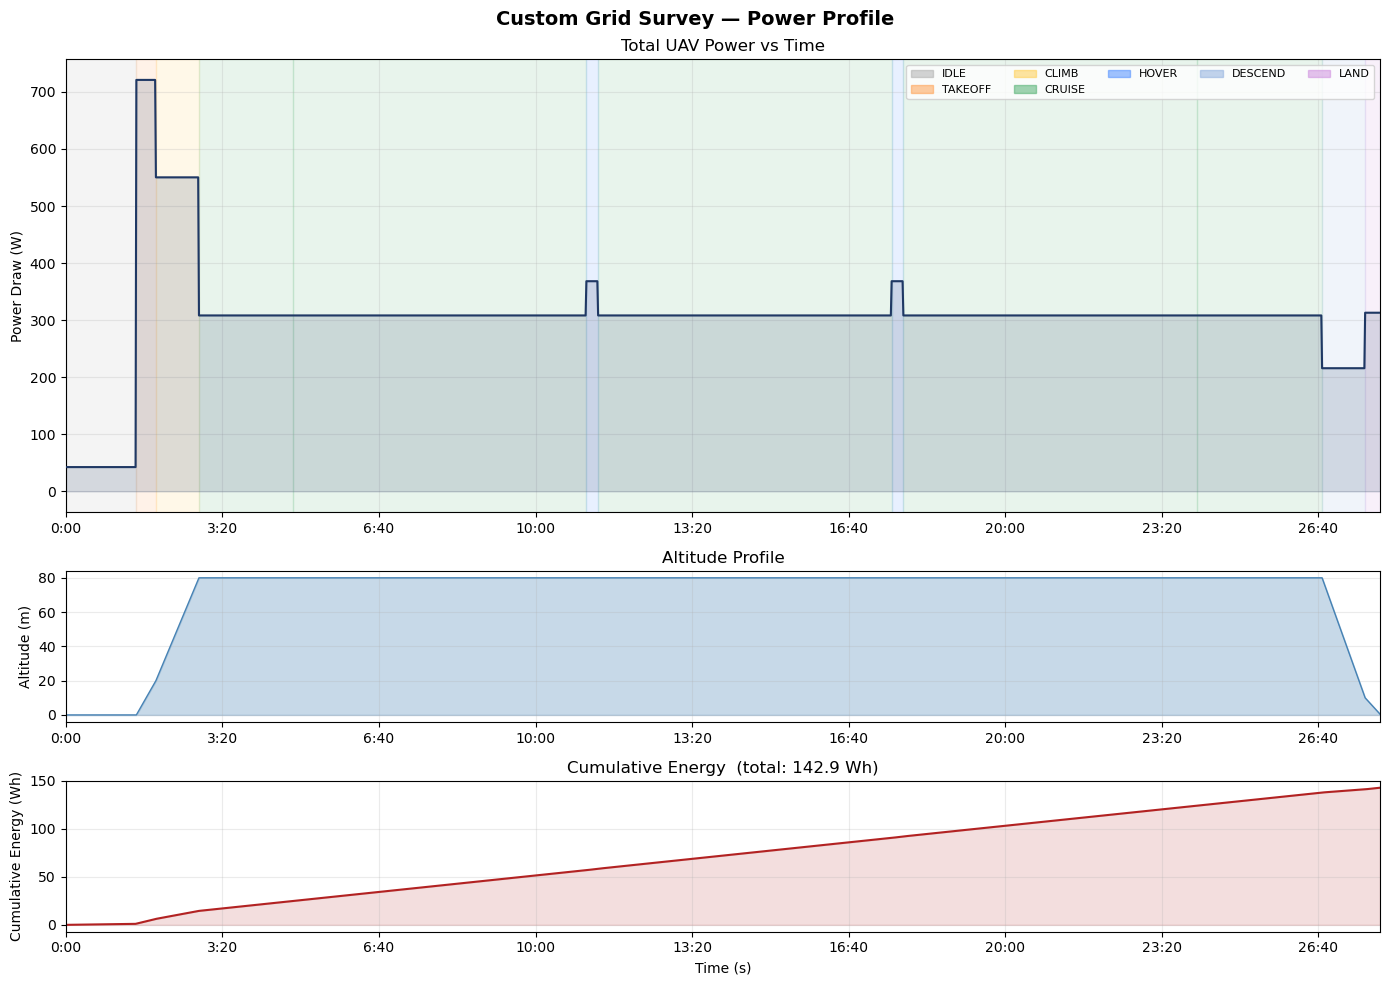

In [8]:
# ── Power Profile Chart ────────────────────────────────────────────────────
times, powers = my_mission.power_profile_w(uav, resolution_s=1.0)

# Phase colour map
PHASE_COLORS = {
    'IDLE':            '#AAAAAA',  # ground idle
    'TAKEOFF':         '#FF9944',  # full power lift-off
    'CLIMB':           '#FFCC44',  # powered climb
    'CRUISE':          '#44AA66',  # level cruise
    'HOVER':           '#4488FF',  # stationary hover
    'DESCEND':         '#88AADD',  # descent
    'LAND':            '#CC88DD',  # landing
    'PAYLOAD_OPS':     '#FF6688',  # payload operations
    'EMERGENCY':       '#FF2222',  # emergency
    # ── Fixed-wing VTOL phases ────────────────────────────────────────
    'VTOL_TRANSITION': '#FF6611',  # lift+thrust overlap during transition
    'VTOL_HOVER':      '#22AAFF',  # explicit multirotor hover
    'FW_CRUISE':       '#00CC77',  # efficient fixed-wing cruise
    'FW_CLIMB':        '#AACC44',  # fixed-wing climb
    'FW_DESCEND':      '#99CCEE',  # glide descent
}

fig, axes = plt.subplots(3, 1, figsize=(14, 10),
                          gridspec_kw={'height_ratios': [3, 1, 1]})
fig.suptitle(f'{my_mission.mission_name} — Power Profile', fontsize=14, fontweight='bold')

# ── Top: Power vs Time with phase shading ──────────────────────────────────
ax_p = axes[0]
ax_p.plot(times, powers, color='#1F3864', linewidth=1.5, zorder=3)
ax_p.fill_between(times, powers, alpha=0.15, color='#1F3864', zorder=2)

# Shade phase regions
t_start = 0
phase_handles = {}
for ph in my_mission.phases:
    t_end  = t_start + ph.duration_s
PHASE_COLORS = {
    'IDLE':            '#AAAAAA',  # ground idle
    'TAKEOFF':         '#FF9944',  # full power lift-off
    'CLIMB':           '#FFCC44',  # powered climb
    'CRUISE':          '#44AA66',  # level cruise
    'HOVER':           '#4488FF',  # stationary hover
    'DESCEND':         '#88AADD',  # descent
    'LAND':            '#CC88DD',  # landing
    'PAYLOAD_OPS':     '#FF6688',  # payload operations
    'EMERGENCY':       '#FF2222',  # emergency
    # ── Fixed-wing VTOL phases ────────────────────────────────────────
    'VTOL_TRANSITION': '#FF6611',  # lift+thrust overlap during transition
    'VTOL_HOVER':      '#22AAFF',  # explicit multirotor hover
    'FW_CRUISE':       '#00CC77',  # efficient fixed-wing cruise
    'FW_CLIMB':        '#AACC44',  # fixed-wing climb
    'FW_DESCEND':      '#99CCEE',  # glide descent
}
    ax_p.axvspan(t_start, t_end, alpha=0.12, color=color, zorder=1)
    mid_t  = (t_start + t_end) / 2
    pw     = ph.effective_power_w(uav)
    if ph.phase_type not in phase_handles:
        phase_handles[ph.phase_type] = mpatches.Patch(
            color=color, alpha=0.5, label=ph.phase_type
        )
    t_start = t_end

ax_p.set_ylabel('Power Draw (W)')
ax_p.set_title('Total UAV Power vs Time')
ax_p.legend(handles=list(phase_handles.values()),
            ncol=5, loc='upper right', fontsize=8)
ax_p.grid(alpha=0.25)
ax_p.set_xlim(0, max(times))

# ── Middle: Altitude profile ───────────────────────────────────────────────
ax_alt = axes[1]
t_alt, alts = [], []
t_now = 0
for ph in my_mission.phases:
    for s in range(int(ph.duration_s)):
        frac = s / max(1, ph.duration_s)
        prev_alt = my_mission.phases[my_mission.phases.index(ph) - 1].altitude_m \
                   if my_mission.phases.index(ph) > 0 else 0
        interp_alt = prev_alt + (ph.altitude_m - prev_alt) * frac
        t_alt.append(t_now + s)
        alts.append(interp_alt)
    t_now += ph.duration_s
ax_alt.fill_between(t_alt, alts, alpha=0.3, color='steelblue')
ax_alt.plot(t_alt, alts, color='steelblue', linewidth=1)
ax_alt.set_ylabel('Altitude (m)')
ax_alt.set_title('Altitude Profile')
ax_alt.grid(alpha=0.25)
ax_alt.set_xlim(0, max(times))

# ── Bottom: Cumulative energy ──────────────────────────────────────────────
ax_e = axes[2]
cumulative_e = np.cumsum(np.array(powers) * 1 / 3600)  # Wh at 1s resolution
ax_e.plot(times, cumulative_e, color='firebrick', linewidth=1.5)
ax_e.fill_between(times, cumulative_e, alpha=0.15, color='firebrick')
ax_e.set_xlabel('Time (s)')
ax_e.set_ylabel('Cumulative Energy (Wh)')
ax_e.set_title(f'Cumulative Energy  (total: {my_mission.total_energy_wh(uav):.1f} Wh)')
ax_e.grid(alpha=0.25)
ax_e.set_xlim(0, max(times))

# Time-axis tick formatter
def fmt_time(x, _):
    return f'{int(x//60)}:{int(x%60):02d}'
for ax in axes:
    ax.xaxis.set_major_formatter(plt.FuncFormatter(fmt_time))

plt.tight_layout()
plt.savefig('power_profile.png', dpi=120, bbox_inches='tight')
plt.show()

In [9]:
# ── Export power profile to CSV ─────────────────────────────────────────────
times, powers = my_mission.power_profile_w(uav, resolution_s=1.0)
df_profile = pd.DataFrame({'time_s': times, 'power_w': powers})
df_profile['cumulative_energy_wh'] = df_profile['power_w'].cumsum() / 3600

# Add phase label column
phase_labels = []
for ph in my_mission.phases:
    phase_labels.extend([ph.phase_type] * int(ph.duration_s))
df_profile['phase'] = phase_labels[:len(df_profile)]

csv_path = f'{MISSION_ID}_power_profile.csv'
df_profile.to_csv(csv_path, index=False)
print(f'✓ Exported {len(df_profile)} rows to {csv_path}')
print(f'  Columns: {list(df_profile.columns)}')
df_profile.head(10)

✓ Exported 1680 rows to MY_MISSION_01_power_profile.csv
  Columns: ['time_s', 'power_w', 'cumulative_energy_wh', 'phase']


,time_s,power_w,cumulative_energy_wh,phase
0,0.0,42.5,0.011806,IDLE
1,1.0,42.5,0.023611,IDLE
2,2.0,42.5,0.035417,IDLE
3,3.0,42.5,0.047222,IDLE
4,4.0,42.5,0.059028,IDLE
5,5.0,42.5,0.070833,IDLE
6,6.0,42.5,0.082639,IDLE
7,7.0,42.5,0.094444,IDLE
8,8.0,42.5,0.106250,IDLE
9,9.0,42.5,0.118056,IDLE


In [10]:
# ── Battery suitability check against mission ──────────────────────────────
# Which packs in the catalog can supply enough energy AND power for this mission?
total_e_needed = my_mission.total_energy_wh(uav)
max_p_needed   = max(ph.effective_power_w(uav) for ph in my_mission.phases)
dod_margin     = 0.80   # use only 80% DoD for safety

print(f'Mission requires: {total_e_needed:.1f} Wh energy, {max_p_needed:.0f} W peak power')
print(f'DoD margin: {dod_margin*100:.0f}%  → need ≥ {total_e_needed/dod_margin:.1f} Wh pack\n')

suitable = []
for p in db.packs.values():
    usable_e = p.pack_energy_wh * dod_margin
    can_power= p.max_cont_discharge_w >= max_p_needed
    can_energy=usable_e >= total_e_needed
    margin_e = (usable_e - total_e_needed) / total_e_needed * 100
    suitable.append({
        'Pack_ID': p.battery_id,
        'Chemistry': p.chemistry_id,
        'Config': f'{p.cells_series}S{p.cells_parallel}P',
        'Energy (Wh)': p.pack_energy_wh,
        'Usable (Wh)': round(usable_e, 1),
        'Energy margin%': round(margin_e, 1),
        'Max P (W)': p.max_cont_discharge_w,
        'Weight (g)': p.pack_weight_g,
        'Wh/kg': p.specific_energy_wh_kg,
        '✓ Energy': '✓' if can_energy else '✗',
        '✓ Power': '✓' if can_power else '✗',
        '✓ Both': '✓' if can_energy and can_power else '✗',
    })

df_suit = (pd.DataFrame(suitable)
             .set_index('Pack_ID')
             .sort_values('Energy margin%', ascending=False))
df_suit

Mission requires: 142.9 Wh energy, 721 W peak power
DoD margin: 80%  → need ≥ 178.6 Wh pack



,Chemistry,Config,Energy (Wh),Usable (Wh),Energy margin%,Max P (W),Weight (g),Wh/kg,✓ Energy,✓ Power,✓ Both
Pack_ID,,,,,,,,,,,
BAT_MID_6S4P,LION21,6S4P,436.00,348.8,144.1,1221.0,1692.0,258.0,✓,✓,✓
BAT_LE_12S2P,LION21,12S2P,350.00,280.0,96.0,3066.0,1656.0,212.0,✓,✓,✓
BAT_MID_6S2P,LION21,6S2P,197.00,157.6,10.3,1971.0,840.0,235.0,✓,✓,✓
BAT_AG_6S1P,LIFEPO4,6S1P,192.00,153.6,7.5,576.0,1860.0,103.0,✓,✗,✗
BAT_SSS_6S1P,SSS,6S1P,111.00,88.8,-37.9,266.0,606.0,183.0,✗,✗,✗
BAT_HLIFT_6S2P,LIFEPO4,6S2P,99.00,79.2,-44.6,2772.0,912.0,109.0,✗,✓,✗
BAT_FPV_4S1P,LIPO,4S1P,19.20,15.4,-89.2,962.0,128.0,150.0,✗,✓,✗
BAT_MICRO_1S,LIHV,1S1P,2.12,1.7,-98.8,19.0,14.0,151.0,✗,✗,✗
